In this notebook, we test our Kalman methods on a 3-dimensional linear dynamical system, with a linearly related 2-dimensional observation space.

In [1]:
import os
import torch
import numpy as np
from matplotlib import pyplot as plt
from time import time
from tensordict import TensorDict
os.chdir('..')
from adda.system.state import State
from adda.system.dynamics import LinearDynamics
from adda.util.visualization import show_1dseqimg
from adda.probability.distributions import DiagonalGaussian
from adda.observation.operators import LinearGaussianObsOp
from adda.kalman.filter import kalman_filter
from adda.kalman.smoother import kalman_smoother
from adda.util.state_space import rollout

# Generate groundtruth time series and observations

In [2]:
n_variables = 3 # 3-dimensional state
initial_state_std = 0.2

# the initial state is sampled from a diagonal Gaussian distribution
initial_mean = State(torch.ones(1, 1, n_variables), torch.zeros(1,))
initial_covariance = State(torch.eye(n_variables).reshape(1, 1, n_variables, n_variables) * initial_state_std **2, torch.zeros(1,))
initial_state = initial_mean + torch.randn(1, 1, n_variables) * initial_state_std

# create an almost antisymmetric matrix
generator_mat = torch.Tensor([[0, 2, 1], [-2, 0, 2], [-1, -2, 0]])*.1 + torch.randn(3,3)*0.01
# our discrete linear system corresponds to the time integration of the almost antisymmetric matrix
m_dyn = LinearDynamics(torch.matrix_exp(generator_mat))

# Here we go for no model error but one can uncomment the line below to use one
model_error_covariance = None
#model_error_covariance = torch.eye(n_variables).unsqueeze(0) * 1e-3

dt = 0.01
n_steps = 200
true_series = rollout(m_dyn, torch.arange(0, n_steps*dt, dt), initial_state)

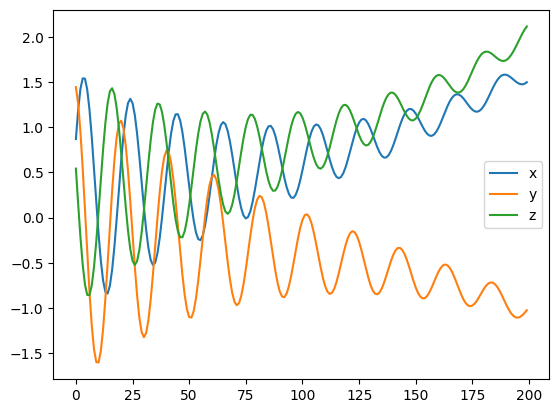

In [3]:
plt.plot(true_series.fields['x'][0,:,0], label='x')
plt.plot(true_series.fields['x'][0,:,1], label='y')
plt.plot(true_series.fields['x'][0,:,2], label='z')
plt.legend()

In [4]:
std = 0.5 # standard deviation of the observations

# We generate a 3x2 observation matrix, so that our observations are 2-dimensional
H = State(torch.Tensor([[[[1,1,1],
                          [1,-1,1]]]]))

# The observation operator is defined using the Cholesky factor of its precision, i.e. of the inverse of its covariance.
P_chol = State(torch.eye(2).reshape(1,1,2,2) / std)
obs_op = LinearGaussianObsOp(H, P_chol)

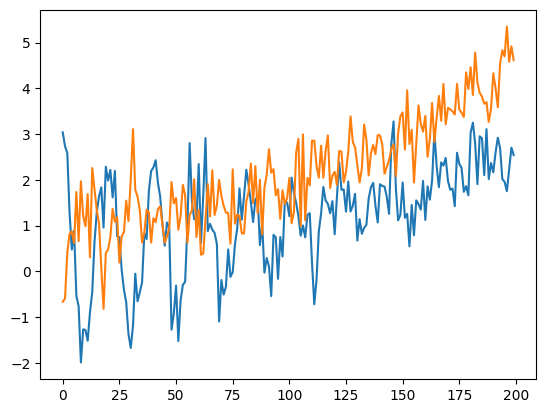

In [5]:
# We now generate and display some observations of the system.
observations = obs_op.sample(true_series)
plt.plot(observations.state.fields['x'][0,:,0])
plt.plot(observations.state.fields['x'][0,:,1])

# Kalman filter

We first use the classical Kalman filter algorithm. Since it performs only a forward pass, it usually has relatively large errors at the beginning of the time range, which decrease as more observations are assimilated.

In [6]:
assimilated_mean_kf, assimilated_covariance_kf = kalman_filter(m_dyn, observations, obs_op, initial_mean, initial_covariance, model_error_covariance)

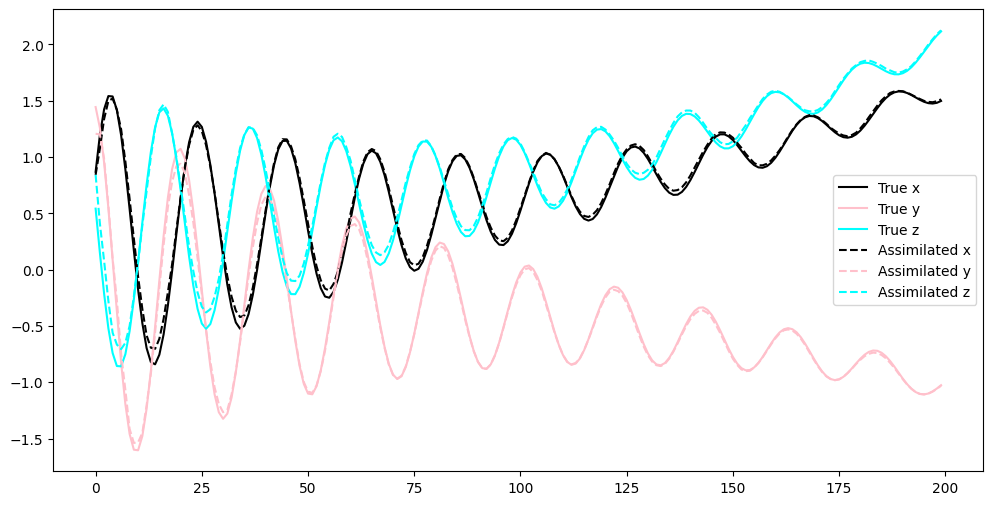

In [7]:
initial_guess_series = State(torch.ones(1, 1, n_variables))
for step in range(n_steps-1):
    current_state = initial_guess_series.restrict_time_domain(dt * (step - 0.5), dt * (step + 0.5))
    initial_guess_series = initial_guess_series.cat(m_dyn(current_state, dt), 1)

plt.figure(figsize=(12,6))
plt.plot(true_series.fields['x'][0,:,0], c='black', label='True x')
plt.plot(true_series.fields['x'][0,:,1], c='pink', label='True y')
plt.plot(true_series.fields['x'][0,:,2], c='cyan', label='True z')
plt.plot(assimilated_mean_kf.fields['x'][0,:,0], c='black', linestyle='--', label='Assimilated x')
plt.plot(assimilated_mean_kf.fields['x'][0,:,1], c='pink', linestyle='--', label='Assimilated y')
plt.plot(assimilated_mean_kf.fields['x'][0,:,2], c='cyan', linestyle='--', label='Assimilated z')
plt.legend()

0.04053749144077301


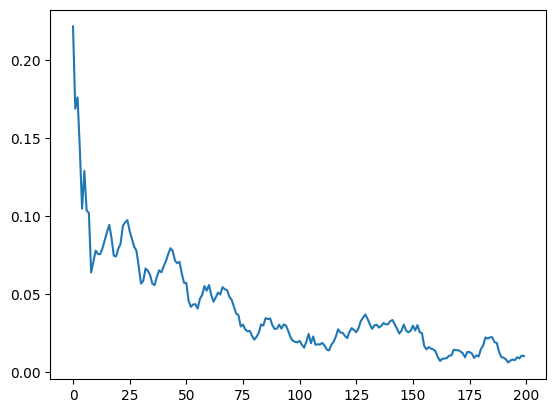

In [8]:
kf_error = (true_series - assimilated_mean_kf).fields['x'][0].clone()
RMSE_over_time_kf = torch.sqrt(torch.mean(kf_error **2, dim=1))
print(torch.mean(RMSE_over_time_kf).item())
plt.plot(RMSE_over_time_kf)

The errors are quite high in the beginning due to an incorrect initialization, but they get smaller as more observations are assimilated.

# RTS Kalman smoother

We now use the most common Kalman smoother algorithm, i.e. the RTS variant, which consists in the succession of a forward pass and a backward pass on the time domain. The RTS smoother is expected to provide a much closer fit to the groundtruth, especially in early time steps.

In [9]:
assimilated_mean_ks, assimilated_covariance_ks = kalman_smoother(m_dyn, observations, obs_op, initial_mean, initial_covariance, model_error_covariance)

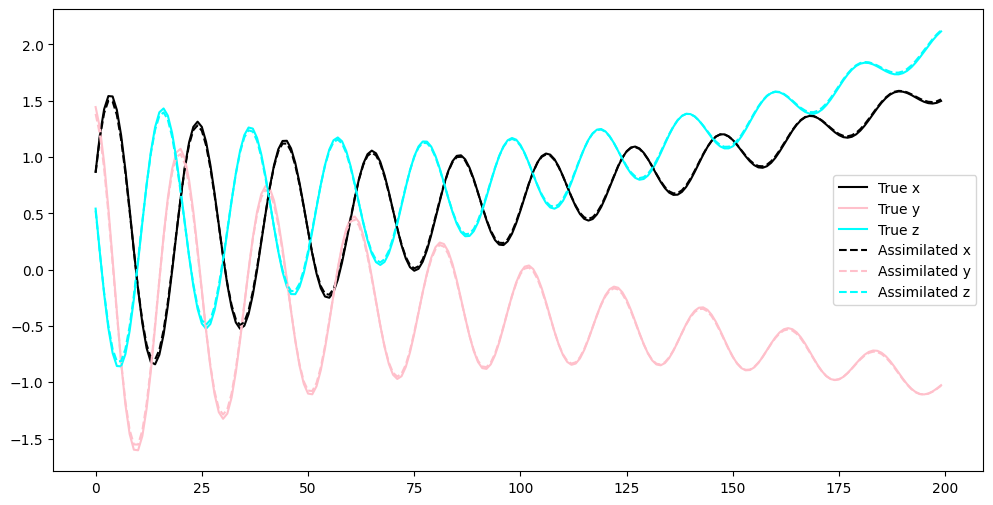

In [10]:
initial_guess_series = State(torch.ones(1, 1, n_variables))
for step in range(n_steps-1):
    current_state = initial_guess_series.restrict_time_domain(dt * (step - 0.5), dt * (step + 0.5))
    initial_guess_series = initial_guess_series.cat(m_dyn(current_state, dt), 1)

plt.figure(figsize=(12,6))
plt.plot(true_series.fields['x'][0,:,0], c='black', label='True x')
plt.plot(true_series.fields['x'][0,:,1], c='pink', label='True y')
plt.plot(true_series.fields['x'][0,:,2], c='cyan', label='True z')
plt.plot(assimilated_mean_ks.fields['x'][0,:,0], c='black', linestyle='--', label='Assimilated x')
plt.plot(assimilated_mean_ks.fields['x'][0,:,1], c='pink', linestyle='--', label='Assimilated y')
plt.plot(assimilated_mean_ks.fields['x'][0,:,2], c='cyan', linestyle='--', label='Assimilated z')
plt.legend()

0.04053749144077301 0.015415067784488201


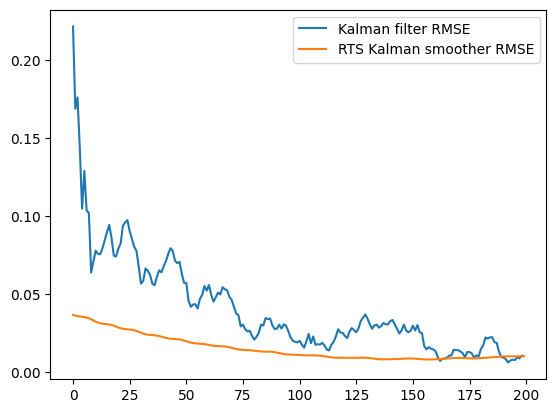

In [11]:
ks_error = (true_series - assimilated_mean_ks).fields['x'][0].clone()
RMSE_over_time_ks = torch.sqrt(torch.mean(ks_error **2, dim=1))
print(torch.mean(RMSE_over_time_kf).item(), torch.mean(RMSE_over_time_ks).item())
plt.plot(RMSE_over_time_kf, label='Kalman filter RMSE')
plt.plot(RMSE_over_time_ks, label='RTS Kalman smoother RMSE')
plt.legend()

As expected, the RTS smoother obtains the same RMSE as the Kalman filter at the end of the observation window, but otherwise has a lower RMSE thanks to the additional smoothing step.